In [ ]:
task 06 :  implement multiple linear regression model on calforniaHousing datatset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [2]:
# 1. Load the dataset
cal_housing = fetch_california_housing()
df = pd.DataFrame(data=cal_housing.data, columns=cal_housing.feature_names)
df['target'] = cal_housing.target

In [3]:
# 2. Select Features and Target
X = df.drop('target', axis=1)
y = df['target']

In [4]:
# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 4. Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 5. Create and Train the Model
mlr_model = LinearRegression()
mlr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# 6. Make Predictions
y_pred = mlr_model.predict(X_test_scaled)

In [8]:
# 7. Evaluate the Model
print('--- Multiple Linear Regression Metrics ---')
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R-squared:', metrics.r2_score(y_test, y_pred))

--- Multiple Linear Regression Metrics ---
MAE: 0.5332001304956564
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R-squared: 0.5757877060324508


In [9]:
# 8. Check Coefficients (Importance of each feature)
coeff_df = pd.DataFrame(mlr_model.coef_, X.columns, columns=['Coefficient'])
print('\n--- Feature Coefficients ---')
print(coeff_df.sort_values(by='Coefficient', ascending=False))


--- Feature Coefficients ---
            Coefficient
MedInc         0.854383
AveBedrms      0.339259
HouseAge       0.122546
Population    -0.002308
AveOccup      -0.040829
AveRooms      -0.294410
Longitude     -0.869842
Latitude      -0.896929


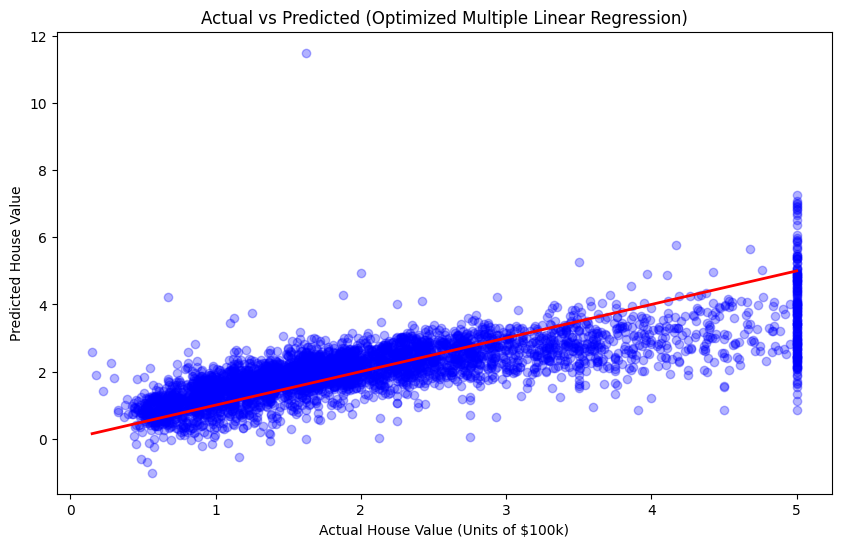

In [10]:
# 9. Visualize: Actual vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual House Value (Units of $100k)')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted (Optimized Multiple Linear Regression)')
plt.show()